# Libraries

In [74]:
import numpy as np
import scipy
from scipy import signal
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import math

# root = str(Path().resolve().parent)
custom_pkg = str(Path().resolve().parent.parent / "python")
if custom_pkg not in sys.path:
    sys.path.append(custom_pkg)
print(*sys.path, sep="\n")

# %matplotlib ipympl
%matplotlib inline

/usr/lib/python312.zip
/usr/lib/python3.12
/usr/lib/python3.12/lib-dynload

/home/ryanwtsai/repos/rfdsp_sim/python/venv/lib/python3.12/site-packages
/home/ryanwtsai/repos/rfdsp_sim/python


In [81]:
from importlib import reload
from rfdsppy import calc, ofdm, rf_analog, rf_tx_fw, \
    tonegen, digital_filter_design, digital_hw_algo as dighw, \
    rf_estimation as rf_est

reload(calc)
reload(ofdm)
reload(rf_analog)
reload(rf_tx_fw)
reload(tonegen)
reload(digital_filter_design)
reload(dighw)
reload(rf_est)

<module 'rfdsppy.rf_estimation' from '/home/ryanwtsai/repos/rfdsp_sim/python/rfdsppy/rf_estimation.py'>

# Coherent averaging

# Incoherent averaging

In [ ]:


noise = rng.normal(loc=0, scale=1, size=4096)

print(noise.mean())
print(noise.var())

-0.0172436308995024
0.991415954098413


(1, 10000)

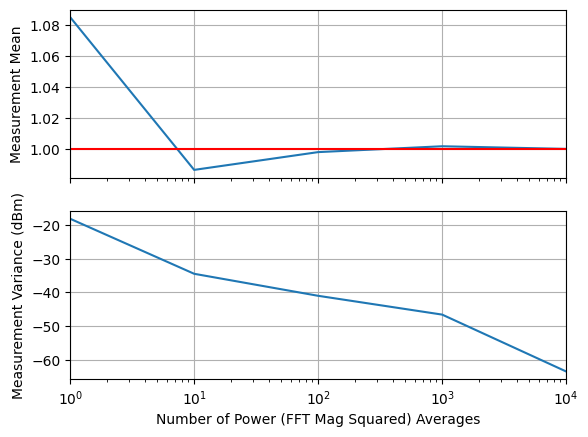

In [ ]:
rng = np.random.default_rng()

# From 128 samples of Gaussian noise, estimate noise power (using estimator for variance)
# Do this N times and average. This is your measurement.
# Do this S times to estimate the measurement mean and variance.


S = 10 # Take S samples to get the sampling distribution
Ns = [2, 4, 8, 16, 32, 64, 128, 256, 512, 1024] # number of "FFTs" to average
Ns = [1, 10, 100, 1000, 10000]

est_var_vs_N = np.zeros(len(Ns), dtype="float")
est_mean_vs_N = np.zeros(len(Ns), dtype="float")
for idx, N in enumerate(Ns):
    power = np.zeros((N, S), dtype="float")
    for sdx in range(S):
        for ndx in range(N):
            noise = rng.normal(loc=0, scale=1, size=128)
            power[ndx, sdx] = noise.var()*128/(127)

    # This is the average power for each sample. 
    # We want the sampling distribution of the average power.
    power_est_per_sample = power.mean(axis=0)

    # Save the mean and variance of the sampling distribution
    est_mean_vs_N[idx] = power_est_per_sample.mean()
    est_var_vs_N[idx] = power_est_per_sample.var() 

fig, ax = plt.subplots(nrows=2, dpi=100, sharex=True)
ax[0].semilogx(Ns, est_mean_vs_N)
ax[0].set_ylabel("Measurement Mean")
ax[0].grid()
ax[0].hlines([1], xmin=min(Ns), xmax=max(Ns), colors="r")
ax[1].semilogx(Ns, 10*np.log10(est_var_vs_N))
ax[1].set_xlabel("Number of Power (FFT Mag Squared) Averages")
ax[1].set_ylabel("Measurement Variance (dBm)")
ax[1].grid()
ax[1].set_xlim(left=min(Ns), right=max(Ns))

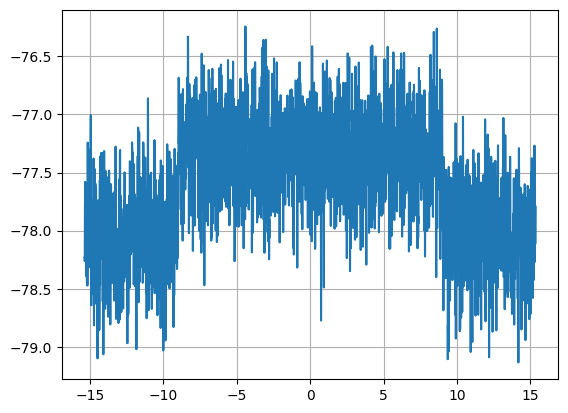

In [133]:
fs = 30.72
fc = 5

awgn = rf_analog.AWGN(8, 20, fs)
# cw = tonegen.tonegen(fs, fc, nsamp=2**16, power=-20)
wg = ofdm.OFDMWavGen(20, 15, 4, 0, power=0)
x, x_standard = wg.generate(14*10)

x_awgn = awgn.transform(x)

p, f = rf_est.sde(x_awgn, fs, fs/2**12)

fig, ax = plt.subplots(dpi=100)

ax.plot(f, 10*np.log10(p))
# ax.plot(f, p)
ax.grid()

In [121]:
p.var()

np.float64(7.829133647584162e-12)

In [112]:
8.820273778705794e-12/5.907572816615662e-13

14.930452916124635

In [122]:
7.829133647584162e-12/1.2782594321099177e-13

61.24839333014938

In [124]:
10*np.log10(math.sqrt(2))

np.float64(1.505149978319906)